##### <p style="text-align: center;"> ![alt text](./utilities/cilss.png)</p>
# <p style="text-align: center;">AGHRYMET RCC-WAS</p>
#### &copy; Mandela HOUNGNIBO 2024 (Find more [here](https://github.com/hmandela))

## Library

In [1]:
from wass2s import *
import importlib
from pathlib import Path
import warnings
import gc
warnings.filterwarnings("ignore")

#### Set forecast working directory

In [2]:
# Set forecast working directory
dir_s2s = "./Agro_PRESASS_2025"

In [3]:
dir_s2s = Path(dir_s2s)
os.makedirs(dir_s2s, exist_ok=True)
### Save consolidated results
hdcst_consolidated = {}
fcst_consolidated = {}
scores_consolidated = {}
### Save score
dir_save_score = f"{dir_s2s}/scores"
os.makedirs(dir_save_score, exist_ok=True)
### Save forecasts
dir_to_forecast = f"{dir_s2s}/forecasts"
os.makedirs(dir_to_forecast, exist_ok=True)

#### Set Climatological Years

In [4]:
# Set Climatological Years
clim_year_start = 1994 #1991
clim_year_end = 2016 #2020
dist_method="nonparam" # "gamma", "t", "lognormal", "normal", "nonparam"
fcst_labels = ["Short", "Near-Normal", "Long"]

## Download Observation and Process 


#### Load Downloader 

In [5]:
# Load WAS_S2S downloader class
downloader = WAS_Download()

In [6]:
# Filter observation names to identify precipitation-related models
variables_obs = [key for key in downloader.AgroObsName().keys() if "PRCP" in key]

# Specify the directory to save downloaded model data
dir_to_save_Obs = f"{dir_s2s}/Observation"

# Define the observation period (years 1993 to 2016)
year_start = 1991
year_end = 2024

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent_obs = [21, -18, 7, 25]   # [Northern, Western, Southern and Eastern] 

# Specify whether to overwrite existing files when downloading data
force_download = False

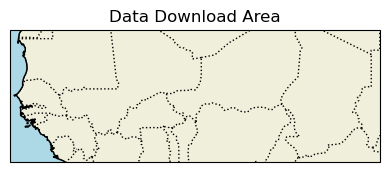

In [7]:
plot_map([extent_obs[1],extent_obs[3],extent_obs[2],extent_obs[0]], title="Data Download Area", fig_size=(4,3))

In [8]:
downloader.WAS_Download_AgroIndicators_daily(dir_to_save_Obs, variables_obs, year_start, year_end, extent_obs, force_download=force_download)
downloader.WAS_Download_AgroIndicators_daily(dir_to_save_Obs, variables_obs, datetime.datetime.now().year, datetime.datetime.now().year, extent_obs, force_download=force_download)

Agro_PRESASS_2025/Observation/Daily_PRCP_1991_2024.nc already exists. Skipping download.
Agro_PRESASS_2025/Observation/Daily_PRCP_2025_2025.nc already exists. Skipping download.


In [9]:
#### Process predictant
rainfall = prepare_predictand(dir_to_save_Obs, variables_obs, year_start, year_end, daily=True, ds=False)
rainfall_for_forecast_year = prepare_predictand(dir_to_save_Obs, variables_obs, datetime.datetime.now().year, datetime.datetime.now().year, daily=True, ds=False)
season_str = agrometparam = "dryspellcessation"
season_obs = [datetime.datetime.now().month+4]

## Compute DrySpellcessation

In [10]:
### Choose number of cores according your computer
nb_cores = 4

In [11]:
## dryspellcessation criteria
user_criteria = cessation_dryspell_criteria
user_criteria

{1: {'zone_name': 'Sahel200_100mm',
  'start_search1': '05-15',
  'cumulative': 15,
  'number_dry_days': 25,
  'thrd_rain_day': 0.85,
  'end_search1': '08-15',
  'nbjour': 40,
  'date_dry_soil': '01-01',
  'start_search2': '09-01',
  'ETP': 5.0,
  'Cap_ret_maxi': 70,
  'end_search2': '10-05'},
 2: {'zone_name': 'Sahel400_200mm',
  'start_search1': '05-01',
  'cumulative': 15,
  'number_dry_days': 20,
  'thrd_rain_day': 0.85,
  'end_search1': '07-31',
  'nbjour': 40,
  'date_dry_soil': '01-01',
  'start_search2': '09-01',
  'ETP': 5.0,
  'Cap_ret_maxi': 70,
  'end_search2': '11-10'},
 3: {'zone_name': 'Sahel600_400mm',
  'start_search1': '03-15',
  'cumulative': 20,
  'number_dry_days': 20,
  'thrd_rain_day': 0.85,
  'end_search1': '07-31',
  'nbjour': 45,
  'date_dry_soil': '01-01',
  'start_search2': '09-15',
  'ETP': 5.0,
  'Cap_ret_maxi': 70,
  'end_search2': '11-15'},
 4: {'zone_name': 'Soudan',
  'start_search1': '03-15',
  'cumulative': 20,
  'number_dry_days': 10,
  'thrd_rain_d

In [12]:
user_criteria[4]["thrd_rain_day"] = 0.85
user_criteria[5]["thrd_rain_day"] = 0.85

##### Compute dryspellcessation for gridded products

In [13]:
# load dryspellcessation class
was_dryspellcessation = WAS_compute_cessation_dry_spell(user_criteria)
dryspellcessation = was_dryspellcessation.compute(daily_data=rainfall, nb_cores=4)

KeyboardInterrupt: 

In [ ]:
dryspellcessation.mean(dim='T').plot()

#### Process dryspellcessation in combining with Ground-Observation

In [ ]:
# ## Path to the CPT file
# cpt_input_file_path = "./Observation/MAM_1991-2023_.txt"

In [ ]:
## Read CSV
# df = pd.read_csv(cpt_input_file_path, na_values=-999.0, sep='\t')
# dryspellcessation_df = df[(df['STATION'] == 'LAT') | (df['STATION'] == 'LON') | 
#                  (pd.to_numeric(df['STATION'], errors='coerce').between(year_start, year_end))]

In [ ]:
## Instantiate WAS_Merging class
# data_merger = WAS_Merging(dryspellcessation_df, dryspellcessation, date_month_day= '02-01')
# dryspellcessation__, _ = data_merger.simple_bias_adjustment(do_cross_validation=False)

In [ ]:
# data_merger.plot_merging_comparaison(dryspellonset_df, dryspellonset , dryspellonset__)

In [ ]:
# dryspellcessation = dryspellcessation__

In [ ]:
# data_merger.plot_merging_comparaison(dryspellcessation_df, dryspellcessation , dryspellcessation__)

# 1st - Approach: Choice of Best Dynamical models and weighted Average

In [ ]:
# Filter model names to identify precipitation-related models 

center_variable = ['ECMWF_51.PRCP', 'METEOFRANCE_8.PRCP',
                   #'UKMO_603.PRCP', # Comment this line if your initialization month starts with March
                   'UKMO_604.PRCP',  # Comment this line if your initialization month starts before April
                   # 'DWD_21.PRCP', # Comment this line if your initialization month starts with March
                   'DWD_22.PRCP', # Comment this line if your initialization month starts before March
                   'CMCC_35.PRCP', 'ECCC_4.PRCP', 'ECCC_5.PRCP', 'JMA_3.PRCP', 'NCEP_2.PRCP'] 


# Specify the directory to save downloaded model data
dir_to_save_model = f"{dir_s2s}/daily_model_data"

# Define the month for model initialization (June)
month_of_initialization = "04"
day_of_initialization ="01"

# Define lead times corresponding to seasonal forecast targets
leadtime_hour = [str(i) for i in range(24, 5161, 24)] 

# Define the hindcast period for model data (years 1993 to 2016)
year_start_model = 1993
year_end_model = 2016

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent_obs = [21, -18, 7, 25]  # [Northern, Western, Southern and Eastern] 

# Define if you want to download forecast or hindcast
forecast = None
ensemble_mean = 'mean',
# Specify whether to overwrite existing files when downloading data
force_download = False

In [ ]:
file_path_hdcst = downloader.WAS_Download_Models_Daily(dir_to_save_model,center_variable,month_of_initialization, day_of_initialization, leadtime_hour, year_start_model, year_end_model, extent_obs, forecast, ensemble_mean, force_download,)

In [ ]:
forecast = 2025

In [ ]:
file_path_fcst = downloader.WAS_Download_Models_Daily(dir_to_save_model,center_variable,month_of_initialization, day_of_initialization, leadtime_hour, year_start_model, year_end_model, extent_obs, forecast, ensemble_mean, force_download,)

In [ ]:
hindcast_files, forecast_files = process_model_for_other_params(was_dryspellcessation, dir_s2s, file_path_hdcst, file_path_fcst, rainfall, 
rainfall_for_forecast_year, month_of_initialization, year_start_model, year_end_model, forecast, nb_cores=2, agrometparam=agrometparam)

In [ ]:
was_verify = WAS_Verification(dist_method=dist_method)

#### Validation of GCM

In [ ]:
score = ["Pearson", "MAE", "GROC"]

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
os.makedirs(dir_save_score, exist_ok=True)
scores = {}
for i in score:
    scores[i] = was_verify.gcm_validation_compute(hindcast_files, dryspellcessation, i, month_of_initialization, clim_year_start, clim_year_end, dir_save_score, lead_time = None, ensemble_mean=None, gridded=True)
    print(was_verify.scores[i][0])
    was_verify.plot_models_score(scores[i], i, dir_save_score)

## Choice of best GCM models

In [ ]:
best_models = get_best_models(center_variable, scores, metric='GROC', threshold=0.5, top_n=4, agroparam=True, gcm=False)
best_models

## MME for best GCM models

In [ ]:
model = WAS_mme_XGBoosting(n_estimators=n_estimators,
                    learning_rate=learning_rate,
                    max_depth=max_depth,
                    random_state=random_state,
                    dist_method=dist_method)

#### Cross-validation

In [ ]:
n_estimators=10
learning_rate=0.1
max_depth=5
random_state=42
dist_method=dist_method

In [ ]:
all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))), hdcsted=hindcast_files, fcsted=forecast_files, scores= scores, gcm=False, agroparam=True, ELM_ELR=False, best_models=best_models)

In [ ]:
was_mme_gcm = WAS_Cross_Validator(n_splits=len(dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))).get_index("T")), nb_omit=2)

In [ ]:
hindcast_det_gcm, hindcast_prob_gcm, = was_mme_gcm.cross_validate(model, obs, all_model_hdcst, clim_year_start, clim_year_end)
hdcst_consolidated['first.approach'] = hindcast_det_gcm

#### Verification

In [ ]:
score = ['Pearson','MAE']
model_name = "MME_best_GCM_Models"

In [ ]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_det_gcm
    )
    scores_consolidated[i] = {'first.approach': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

##### Probabilistic

In [ ]:
score = ['GROC']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_prob_gcm,
        clim_year_start,
        clim_year_end)
    scores_consolidated[i] = {'first.approach': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

#### Forecast 

In [ ]:
forecast_det_gcm, forecast_prob_gcm= model.forecast(obs, clim_year_start, clim_year_end, all_model_hdcst, hindcast_det_gcm, all_model_fcst)
fcst_consolidated['first.approach'] = forecast_det_gcm
plot_prob_forecasts(dir_to_forecast, forecast_prob_gcm.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast}", reverse_cmap=True, labels=fcst_labels))
gc.collect()

# 2nd - Approach: Statistico-Dynamical

In [16]:
# Filter model names to identify precipitation-related models
center_variable =  [key for key in downloader.ModelsName().keys() if "PRCP" in key]
center_variable.remove('UKMO_603.PRCP')


# Specify the directory to save downloaded model data
dir_to_save_model = f"{dir_s2s}/model_data"

# Define the month for model initialization (June)
month_of_initialization = "04"

# Define lead times corresponding to seasonal forecast targets (JAS season in this case)
lead_time = ["04", "05", "06"]  # July-August-September forecast period

# Define the hindcast period for model data (years 1993 to 2016)
year_start_model = 1993
year_end_model = 2016

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent = [30, -30, 0, 30] #[60, -180, -60, 180]  # [Northern, Western, Southern and Eastern] 

# Define if you want to download forecast or hindcast
forecast = None

# Define if you want all members of ensemble or doing an ensemble mean
ensemble_mean = "mean"

# Specify whether to overwrite existing files when downloading data
force_download = False

In [ ]:
hindcast_files = downloader.WAS_Download_Models(
    dir_to_save_model,
    center_variable,
    month_of_initialization,
    lead_time,
    year_start_model,
    year_end_model,
    extent, 
    forecast,
    ensemble_mean,
    force_download)

Agro_PRESASS_2025/model_data/hindcast_ecmwf51_PRCP_AprIc_AugSepOct_04.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/hindcast_ukmo604_PRCP_AprIc_AugSepOct_04.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/hindcast_meteofrance8_PRCP_AprIc_AugSepOct_04.nc already exists. Skipping download.


2025-04-20 13:40:55,709 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-04-20 13:40:55,720 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.
2025-04-20 13:40:56,363 INFO Request ID is 3f890047-84b1-42ef-b4ef-80c38fc27a2b
2025-04-20 13:40:56,585 INFO status has been updated to accepted
2025-04-20 13:41:11,349 INFO status has been updated to running


In [ ]:
forecast = 2025

In [ ]:
forecast_files = downloader.WAS_Download_Models(
    dir_to_save_model,
    center_variable,
    month_of_initialization,
    lead_time,
    year_start_model,
    year_end_model,
    extent, 
    forecast,
    ensemble_mean,
    force_download)

### Initialize the WAS_CCA class (default)

In [ ]:
n_modes = 4
# define zone as dict : {'zone_name_key': ('Explicit_Zone_name', lon_min, lon_max, lat_min, lat_max)} 
defined_zone = {'A': ('A', -30, 30, 0, 30)} 

In [ ]:
plot_map([extent[1],extent[3],extent[2],extent[0]], sst_indices = defined_zone, title="Predictors Area",fig_size=(6,4))

##### Modes of CCA for each model

In [ ]:
was_cca = WAS_CCA(n_modes=n_modes, n_pca_modes=10, dist_method=dist_method)
was_cv = WAS_Cross_Validator(n_splits=len(dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))).get_index("T")), nb_omit=2)

In [ ]:
predictors = {}
for i in center_variable:
    predictors[i] = retrieve_single_zone_for_PCR(dir_to_save_model, defined_zone, i, year_start_model, year_end_model, clim_year_start=clim_year_start, clim_year_end=clim_year_end, model=True, month_of_initialization=month_of_initialization, lead_time=lead_time)
    predictor = predictors[i].isel(T = slice(None,-1))
    predictor['T'] = dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model)))['T']
    print(f"CCA Modes for model {i}")
    was_cca.plot_cca_results(X=predictor, Y=dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))) , clim_year_start=clim_year_start, clim_year_end=clim_year_end)

#### Cross validation

In [ ]:
hindcast_det_dynam_all = {}
hindcast_prob_dynam_all = {}
for key, predictor in predictors.items():
    predictor = predictor.isel(T = slice(None,-1))
    predictor['T'] = dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model)))['T']
    print(key.split(".")[0])
    hindcast_det_dynam_all[key], hindcast_prob_dynam_all[key] = was_cv.cross_validate(was_cca, dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))).sel(T=slice(str(year_start_model),str(year_end_model))), predictor, clim_year_start, clim_year_end)

#### Verification (individual)

###### Deterministic

In [ ]:
score = ['Pearson','MAE']
model_name = "CCA_2nd_Approch"

In [ ]:
cca_scores = {}
tmp = {}
for i in score:
    print(was_verify.scores[i][0])
    for key, hdcst in hindcast_det_dynam_all.items():
        tmp[key] = was_verify.compute_deterministic_score(
            was_verify.get_scores_metadata()[i][5],
            dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))),
            hindcast_det_dynam_all[key]
        )
        was_verify.plot_model_score(tmp[key], i, dir_save_score, f"{key}_{model_name}")
    cca_scores[i] = tmp

###### Probabilistic

In [ ]:
score = ['GROC']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
tmp = {}
for i in score:
    print(was_verify.scores[i][0])
    for key, hdcst in hindcast_det_dynam_all.items():
        tmp[key] = was_verify.compute_probabilistic_score(
            was_verify.get_scores_metadata()[i][5],
            dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))),
            hindcast_prob_dynam_all[key],
            clim_year_start,
            clim_year_end)
        was_verify.plot_model_score(tmp[key], i, dir_save_score, f"{key}_{model_name}")
    cca_scores[i] = tmp

#### Forecast (individual)

In [ ]:
forecast_det_dynam_all = {}
forecast_prob_dynam_all = {}
for key, predictor in predictors.items():
    predictor_f = predictor.isel(T=[-1])
    predictor = predictor.isel(T = slice(None,-1))
    predictor['T'] = dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model)))['T']
    print(key.split(".")[0])
    forecast_det_dynam_all[key], forecast_prob_dynam_all[key] = was_cca.forecast(dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, predictor, hindcast_det_dynam_all[key], predictor_f)
    plot_prob_forecasts(dir_to_forecast, forecast_prob_dynam_all[key].drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast}", reverse_cmap=True, labels=fcst_labels)

### MME 2nd-Approach: Statistico-Dynamical

In [ ]:
#### Select some models
best_models = get_best_models(center_variable, cca_scores, metric='Pearson', threshold=0.5, top_n=7, gcm=False)
best_models

In [ ]:
was_2nd_mme = WAS_mme_Weighted(equal_weighted=False, dist_method=dist_method, metric="Pearson", threshold=0.5)

In [ ]:
all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))),hdcsted=hindcast_det_dynam_all, fcsted=forecast_det_dynam_all, gcm=False, ELM_ELR=False,  best_models=best_models, scores=cca_scores, model=False)
hindcast_det_mme_2nd, forecast_det_mme_2nd  = was_2nd_mme.compute(obs, all_model_hdcst, all_model_fcst, best_score, threshold=0.5, complete=True)
hindcast_prob_mme_2nd = was_2nd_mme.compute_prob(dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, hindcast_det_mme_2nd)
hdcst_consolidated['snd.approach'] = hindcast_det_mme_2nd

#### Verification

###### Deterministic

In [ ]:
score = ['Pearson','MAE']
model_name = "MME_2nd_Approach"

In [ ]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_det_mme_2nd
    )
    scores_consolidated[i]['snd.approach'] = r
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

###### Probabilistic

In [ ]:
score = ['GROC']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_prob_mme_2nd,
        clim_year_start,
        clim_year_end)
    scores_consolidated[i]['snd.approach'] = r
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

#### Forecast 

In [ ]:
forecast_prob_mme_2nd = was_2nd_mme.forecast(dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, hindcast_det_mme_2nd, forecast_det_mme_2nd)
fcst_consolidated['snd.approach'] = forecast_det_mme_2nd
plot_prob_forecasts(dir_to_forecast, forecast_prob_mme_2nd.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast}", reverse_cmap=True, labels=fcst_labels)

# 4th - Analog-based seasonal forecast

## Initialize WAS_Analog class

In [ ]:
## Load class for model, cross-validation and verification
model = WAS_Analog(f"{dir_s2s}/analog", 
                    1990, 2025,"NOAA.SST", "NCEP_2.SST",
                    method_analog ="cor_based", 
                    month_of_initialization=3,
                    clim_year_start=clim_year_start, 
                    clim_year_end=clim_year_end,
                    define_extent = [-180, 180, -60, 60],
                    dist_method=dist_method
                    )

#### Cross-validation

In [ ]:
was_analog_cv = WAS_Cross_Validator(n_splits=len(dryspellcessation.get_index("T")), nb_omit=2)

In [ ]:
hindcast_analog_det, hindcast_analog_prob = was_analog_cv.cross_validate(model, dryspellcessation, clim_year_start=clim_year_start, clim_year_end=clim_year_end)
hdcst_consolidated['fourth.approach'] = hindcast_analog_det.sel(T=slice(str(year_start_model),str(year_end_model)))

#### Verification

###### Deterministic

In [ ]:
score = ['Pearson','MAE']
model_name = "analog_method"

In [ ]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellcessation,
        hindcast_analog_det
    )
    scores_consolidated[i]['fourth.approach'] = r
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

###### Probabilistic

In [ ]:
score = ['GROC']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellcessation,
        hindcast_analog_prob,
        clim_year_start,
        clim_year_end)
    scores_consolidated[i]['fourth.approach'] = r
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

#### Forecast

In [ ]:
ddd, similar_years, forecast_det_analog, forecast_prob_analog = model.forecast(dryspellcessation, clim_year_start, clim_year_end, hindcast_analog_det, forecast)
fcst_consolidated['fourth.approach'] = forecast_det_analog
plot_prob_forecasts(dir_to_forecast, forecast_prob_analog.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast}", reverse_cmap=True, labels=fcst_labels)

In [ ]:
## Analysis SST evolution
model.composite_plot(dryspellcessation, clim_year_start, clim_year_end, hindcast_analog_det, plot_predictor=True)

# Consolidated Forecasts

In [ ]:
best_models = ["first.approach", 'snd.approach', 'fourth.approach']

#### Cross-validation

In [ ]:
all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))),hdcsted=hdcst_consolidated, fcsted=fcst_consolidated, gcm=False, ELM_ELR=False,  best_models=best_models, scores=scores_consolidated, model=False)

In [ ]:
was_mme = WAS_mme_Weighted(equal_weighted=False, dist_method=dist_method, metric="Pearson", threshold=0.5) 

In [ ]:
hindcast_det, forecast_det  = was_mme.compute(obs, all_model_hdcst, all_model_fcst, best_score, complete=True)
hindcast_prob = was_mme.compute_prob(dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, hindcast_det)

#### Consolidated forecast Skill

In [ ]:
score = ['Pearson','MAE']
model_name = "Consolidated Forecast"

###### Deterministic

In [ ]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_det
    )
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

##### Probabilistic

In [ ]:
score = ['GROC']

In [ ]:
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_prob,
        clim_year_start,
        clim_year_end) 
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

### Forecast 

In [ ]:
forecast_prob = was_mme.forecast(dryspellcessation.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, hindcast_det, forecast_det)
plot_prob_forecasts(dir_to_forecast, forecast_prob.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast}", reverse_cmap=True, labels=fcst_labels)

#### Save Forecast for future evaluation

In [ ]:
forecast_det.to_netcdf(f'{dir_to_forecast}/Forecast_Det{season_str}_{forecast}.nc')

In [ ]:
forecast_prob.to_netcdf(f'{dir_to_forecast}/Forecast_Prob{season_str}_{forecast}.nc')

###       ------------------------------------------------------- END --------------------------------------------------

In [ ]:
!jupyter nbconvert --to html --no-input ./01_MME_DrySpellCessation.ipynb